# Decision Trees — Concept, Implementation & Evaluation


## 1. What is a Decision Tree?

So far, we have learned models that draw mathematical boundaries — Logistic Regression draws a line based on probabilities, SVM draws a line based on maximum margin. Today we learn something completely different: a model that makes decisions by asking a **series of questions**.

A Decision Tree works exactly like a game of "20 Questions." Imagine you are trying to identify an animal:

- *"Does it have fur?"* → Yes
- *"Does it bark?"* → Yes
- *"Is it larger than a cat?"* → Yes
- **Prediction: Dog**

Each question splits the possibilities into smaller groups until you arrive at an answer. A Decision Tree does exactly this with data — it learns a sequence of **if-then-else** rules from the training data.

### Why Decision Trees Matter

Decision Trees are special for several reasons:

1. **Interpretability** — You can look at the tree and understand exactly *why* the model made a particular prediction. Try doing that with an SVM kernel or a neural network. This makes Decision Trees invaluable in fields like healthcare and finance where you need to explain your model's decisions.

2. **No feature scaling needed** — Unlike Logistic Regression and SVM, Decision Trees do not care about the scale of features. They make splits based on thresholds, so whether a feature ranges from 0-1 or 0-10,000 does not matter.

3. **Handles both numerical and categorical data** — Naturally suited for mixed data types.

4. **Non-linear decision boundaries** — The tree can create complex, rectangular decision regions by combining multiple splits.

5. **Foundation for powerful ensemble methods** — Random Forests and Gradient Boosting (which we will learn later) are built on Decision Trees.

## 2. Anatomy of a Decision Tree

Let us understand the structure:

- **Root Node** — The topmost node. The first question asked. It represents the entire dataset before any splitting.

- **Internal Nodes** — Each internal node asks a question about a feature (e.g., "Is mean radius ≤ 14.5?"). Based on the answer, the data flows left (Yes) or right (No).

- **Branches** — The connections between nodes. Each branch represents the outcome of a question (Yes/No, or ≤ / >).

- **Leaf Nodes** — The terminal nodes. They do not ask any more questions — they give the final **prediction**. For classification, the leaf predicts the majority class of the training samples that ended up in that leaf.

- **Depth** — The length of the longest path from the root to a leaf. A tree with depth=1 asks only one question (called a "stump"). A tree with depth=20 asks up to 20 sequential questions.

### How Does the Tree Decide Which Question to Ask?

This is the key question. At every node, the tree considers every possible feature and every possible threshold value. It picks the split that creates the **purest** child nodes — meaning the child nodes should ideally contain only one class.

But how do we measure "purity"? That is where **Gini Impurity** and **Entropy** come in.

## 3. Splitting Criteria — Gini Impurity and Entropy

### Gini Impurity

Gini Impurity measures how often a randomly chosen sample from the node would be **misclassified** if it were randomly labeled according to the distribution of classes in the node.

$$\text{Gini} = 1 - \sum_{i=1}^{C} p_i^2$$

Where $p_i$ is the proportion of class $i$ in the node.

- **Gini = 0** → The node is perfectly pure (all samples belong to one class). This is the best possible outcome.
- **Gini = 0.5** (for 2 classes) → Maximum impurity. The classes are equally mixed — the node has no predictive value.

**Example:** A node with 80 benign and 20 malignant samples:
- $p_{benign} = 0.8$, $p_{malignant} = 0.2$
- Gini = $1 - (0.8^2 + 0.2^2) = 1 - (0.64 + 0.04) = 0.32$

A node with 100 benign and 0 malignant:
- Gini = $1 - (1.0^2) = 0$ → perfectly pure

### Entropy

Entropy measures the **disorder** or **uncertainty** in a node. It comes from information theory.

$$\text{Entropy} = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

- **Entropy = 0** → The node is perfectly pure.
- **Entropy = 1** (for 2 classes) → Maximum disorder. Classes are equally mixed.

### Information Gain

When we split a node, we want the resulting child nodes to be purer than the parent. **Information Gain** measures how much purity we gained by making a split:

$$\text{Information Gain} = \text{Impurity}_{parent} - \sum \frac{n_{child}}{n_{parent}} \times \text{Impurity}_{child}$$

The tree picks the split that maximizes information gain. In practice, Gini and Entropy usually produce very similar trees. Scikit-learn uses **Gini** by default.

### Gini vs Entropy — Which to Use?

- **Gini** is slightly faster to compute (no logarithm)
- **Entropy** tends to produce slightly more balanced trees
- In practice, the difference is negligible. Stick with the default (Gini) unless you have a reason to switch.

## 4. Overfitting in Decision Trees — A Critical Problem

Decision Trees have a well-known weakness: they are **extremely prone to overfitting**. An unrestricted tree will keep splitting until every leaf is perfectly pure — meaning each leaf contains only one class. This sounds great, but it means the tree has memorized every single training sample, including noise.

Imagine a tree that creates a unique path for every patient in the training set. It would have 100% training accuracy but would be useless on new patients because it has learned individual quirks rather than general patterns.

### How to Prevent Overfitting (Pruning)

We control tree complexity using hyperparameters — this is called **pruning**:

- **`max_depth`** — Limits how deep the tree can grow. A tree with max_depth=3 asks at most 3 questions. This is the most important hyperparameter.

- **`min_samples_split`** — The minimum number of samples a node must have to be split further. If a node has fewer samples than this, it becomes a leaf. Default is 2 (which allows very small nodes).

- **`min_samples_leaf`** — The minimum number of samples a leaf node must contain. Prevents creating leaves with very few samples (which are likely to be noise).

- **`max_features`** — The number of features to consider at each split. Using fewer features adds randomness and reduces overfitting. (This becomes very important in Random Forests.)

- **`max_leaf_nodes`** — Limits the total number of leaf nodes.

Without pruning, a Decision Tree will almost always overfit. With proper pruning, it can be a powerful and interpretable model.

---

## 5. Setup and Imports

**Task:** Import all required libraries.

In [1]:
# Import numpy, pandas, matplotlib.pyplot, seaborn

# From sklearn.model_selection import train_test_split

# From sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# From sklearn.metrics import (accuracy_score, classification_report,
#                               confusion_matrix, roc_curve, roc_auc_score)

# From sklearn.datasets import load_breast_cancer

# Set seaborn style and random seed (42)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, roc_auc_score)
from sklearn.datasets import load_breast_cancer


---

## 6. Visualizing Gini Impurity

Before we build any model, let us actually **see** how Gini Impurity behaves. We will plot Gini as a function of the proportion of the positive class in a binary classification problem. This builds the intuition for why the tree prefers certain splits over others.

**Task:** Plot Gini Impurity as a function of class proportion.

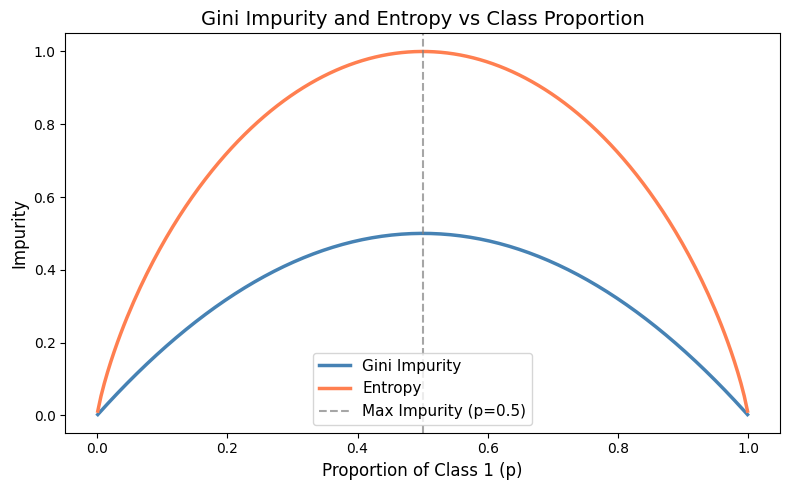

In [2]:
# Create an array of proportions from 0 to 1 (e.g., np.linspace(0, 1, 100))

# Compute Gini for each proportion: gini = 1 - (p^2 + (1-p)^2)

# Also compute Entropy: entropy = -(p*log2(p) + (1-p)*log2(1-p))
# Handle p=0 and p=1 cases (log(0) is undefined)

# Create a figure with figsize=(8, 5)
# Plot proportion vs Gini
# Plot proportion vs Entropy (on same axes, different color)
# Add vertical line at p=0.5
# Add title: 'Gini Impurity and Entropy vs Class Proportion'
# Add labels, legend
# Show the plot


p = np.linspace(0.001, 0.999, 200)

gini = 1 - (p**2 + (1 - p)**2)
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

plt.figure(figsize=(8, 5))
plt.plot(p, gini, color='steelblue', linewidth=2.5, label='Gini Impurity')
plt.plot(p, entropy, color='coral', linewidth=2.5, label='Entropy')
plt.axvline(x=0.5, color='grey', linestyle='--', alpha=0.7, label='Max Impurity (p=0.5)')

plt.title('Gini Impurity and Entropy vs Class Proportion', fontsize=14)
plt.xlabel('Proportion of Class 1 (p)', fontsize=12)
plt.ylabel('Impurity', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


**What to observe:** Both curves peak at p=0.5 (maximum impurity — classes are equally mixed) and reach zero at p=0 and p=1 (perfect purity). The tree's goal at each split is to move from the peak toward the edges — from mixed to pure.

---

## 7. Loading and Exploring the Dataset

We continue using the Breast Cancer dataset for consistency with Days 48 and 50. This allows direct comparison of Decision Tree performance against Logistic Regression and SVM.

**Notice:** Unlike Logistic Regression and SVM, we do **not** need to scale the features for Decision Trees. Trees make splits based on thresholds, so the absolute scale of features does not matter.

**Task:** Load the data and split into train/test sets.

In [3]:
# Load the Breast Cancer dataset (as_frame=True)

# Separate X and y

# Split into train/test (test_size=0.2, random_state=42, stratify=y)

# Print shapes and class distribution

# Note: NO scaling needed for Decision Trees

cancer = load_breast_cancer(as_frame=True)

X = cancer.data
y = cancer.target

X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)


print(f"Breast Cancer Dataset loaded")
print(f"  Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"  Test set:     {X_test.shape[0]} samples")
print(f"  Classes: 0=Malignant ({(y_train == 0).sum()} train), 1=Benign ({(y_train == 1).sum()} train)")
print(f"\n  NOTE: No feature scaling needed for Decision Trees!")


Breast Cancer Dataset loaded
  Training set: 455 samples, 30 features
  Test set:     114 samples
  Classes: 0=Malignant (170 train), 1=Benign (285 train)

  NOTE: No feature scaling needed for Decision Trees!


---

## 8. Building an Unrestricted Decision Tree (Overfitting Demo)

First, let us build a Decision Tree with **no restrictions** — no max_depth, no min_samples. This will grow the tree until every leaf is pure. We do this deliberately to see how badly a Decision Tree can overfit.

**Task:** Train an unrestricted Decision Tree and evaluate it.

In [4]:
# Create a DecisionTreeClassifier with random_state=42 (no other constraints)

# Fit on X_train, y_train (no scaling needed)

# Compute training accuracy

# Compute test accuracy

# Print both accuracies and the gap

# Print the tree's depth using model.get_depth()

# Print the number of leaves using model.get_n_leaves()

dt_unrestricted = DecisionTreeClassifier(random_state=42)
dt_unrestricted.fit(X_train, y_train)

train_acc_ur = accuracy_score(y_train, dt_unrestricted.predict(X_train))
test_acc_ur = accuracy_score(y_test, dt_unrestricted.predict(X_test))

gap_ur = train_acc_ur - test_acc_ur



print("=" * 50)
print("  UNRESTRICTED DECISION TREE")
print("=" * 50)
print(f"  Training Accuracy:  {train_acc_ur:.4f} ({train_acc_ur:.1%})")
print(f"  Test Accuracy:      {test_acc_ur:.4f} ({test_acc_ur:.1%})")
print(f"  Gap:                {gap_ur:.4f}")
print(f"  Tree Depth:         {dt_unrestricted.get_depth()}")
print(f"  Number of Leaves:   {dt_unrestricted.get_n_leaves()}")
print("=" * 50)
if train_acc_ur >= 0.99:
    print("  ⚠ Training accuracy is ~100% — the tree has memorized the data!")
if gap_ur > 0.03:
    print(f"  ⚠ Gap of {gap_ur:.4f} confirms overfitting.")

  UNRESTRICTED DECISION TREE
  Training Accuracy:  1.0000 (100.0%)
  Test Accuracy:      0.9123 (91.2%)
  Gap:                0.0877
  Tree Depth:         7
  Number of Leaves:   19
  ⚠ Training accuracy is ~100% — the tree has memorized the data!
  ⚠ Gap of 0.0877 confirms overfitting.


**What to observe:** The training accuracy should be **100%** (or very close to it) — the tree has memorized every training sample. But the test accuracy will be lower — the gap between them reveals overfitting. Also note the depth and number of leaves — an unrestricted tree can be surprisingly deep and complex.

### 8.1 Visualizing the Unrestricted Tree

Let us try to visualize this overgrown tree. Scikit-learn's `plot_tree` function can render it, but it will be massive and unreadable — which is exactly the point. This is what an overfit tree looks like.

**Task:** Visualize the unrestricted tree.

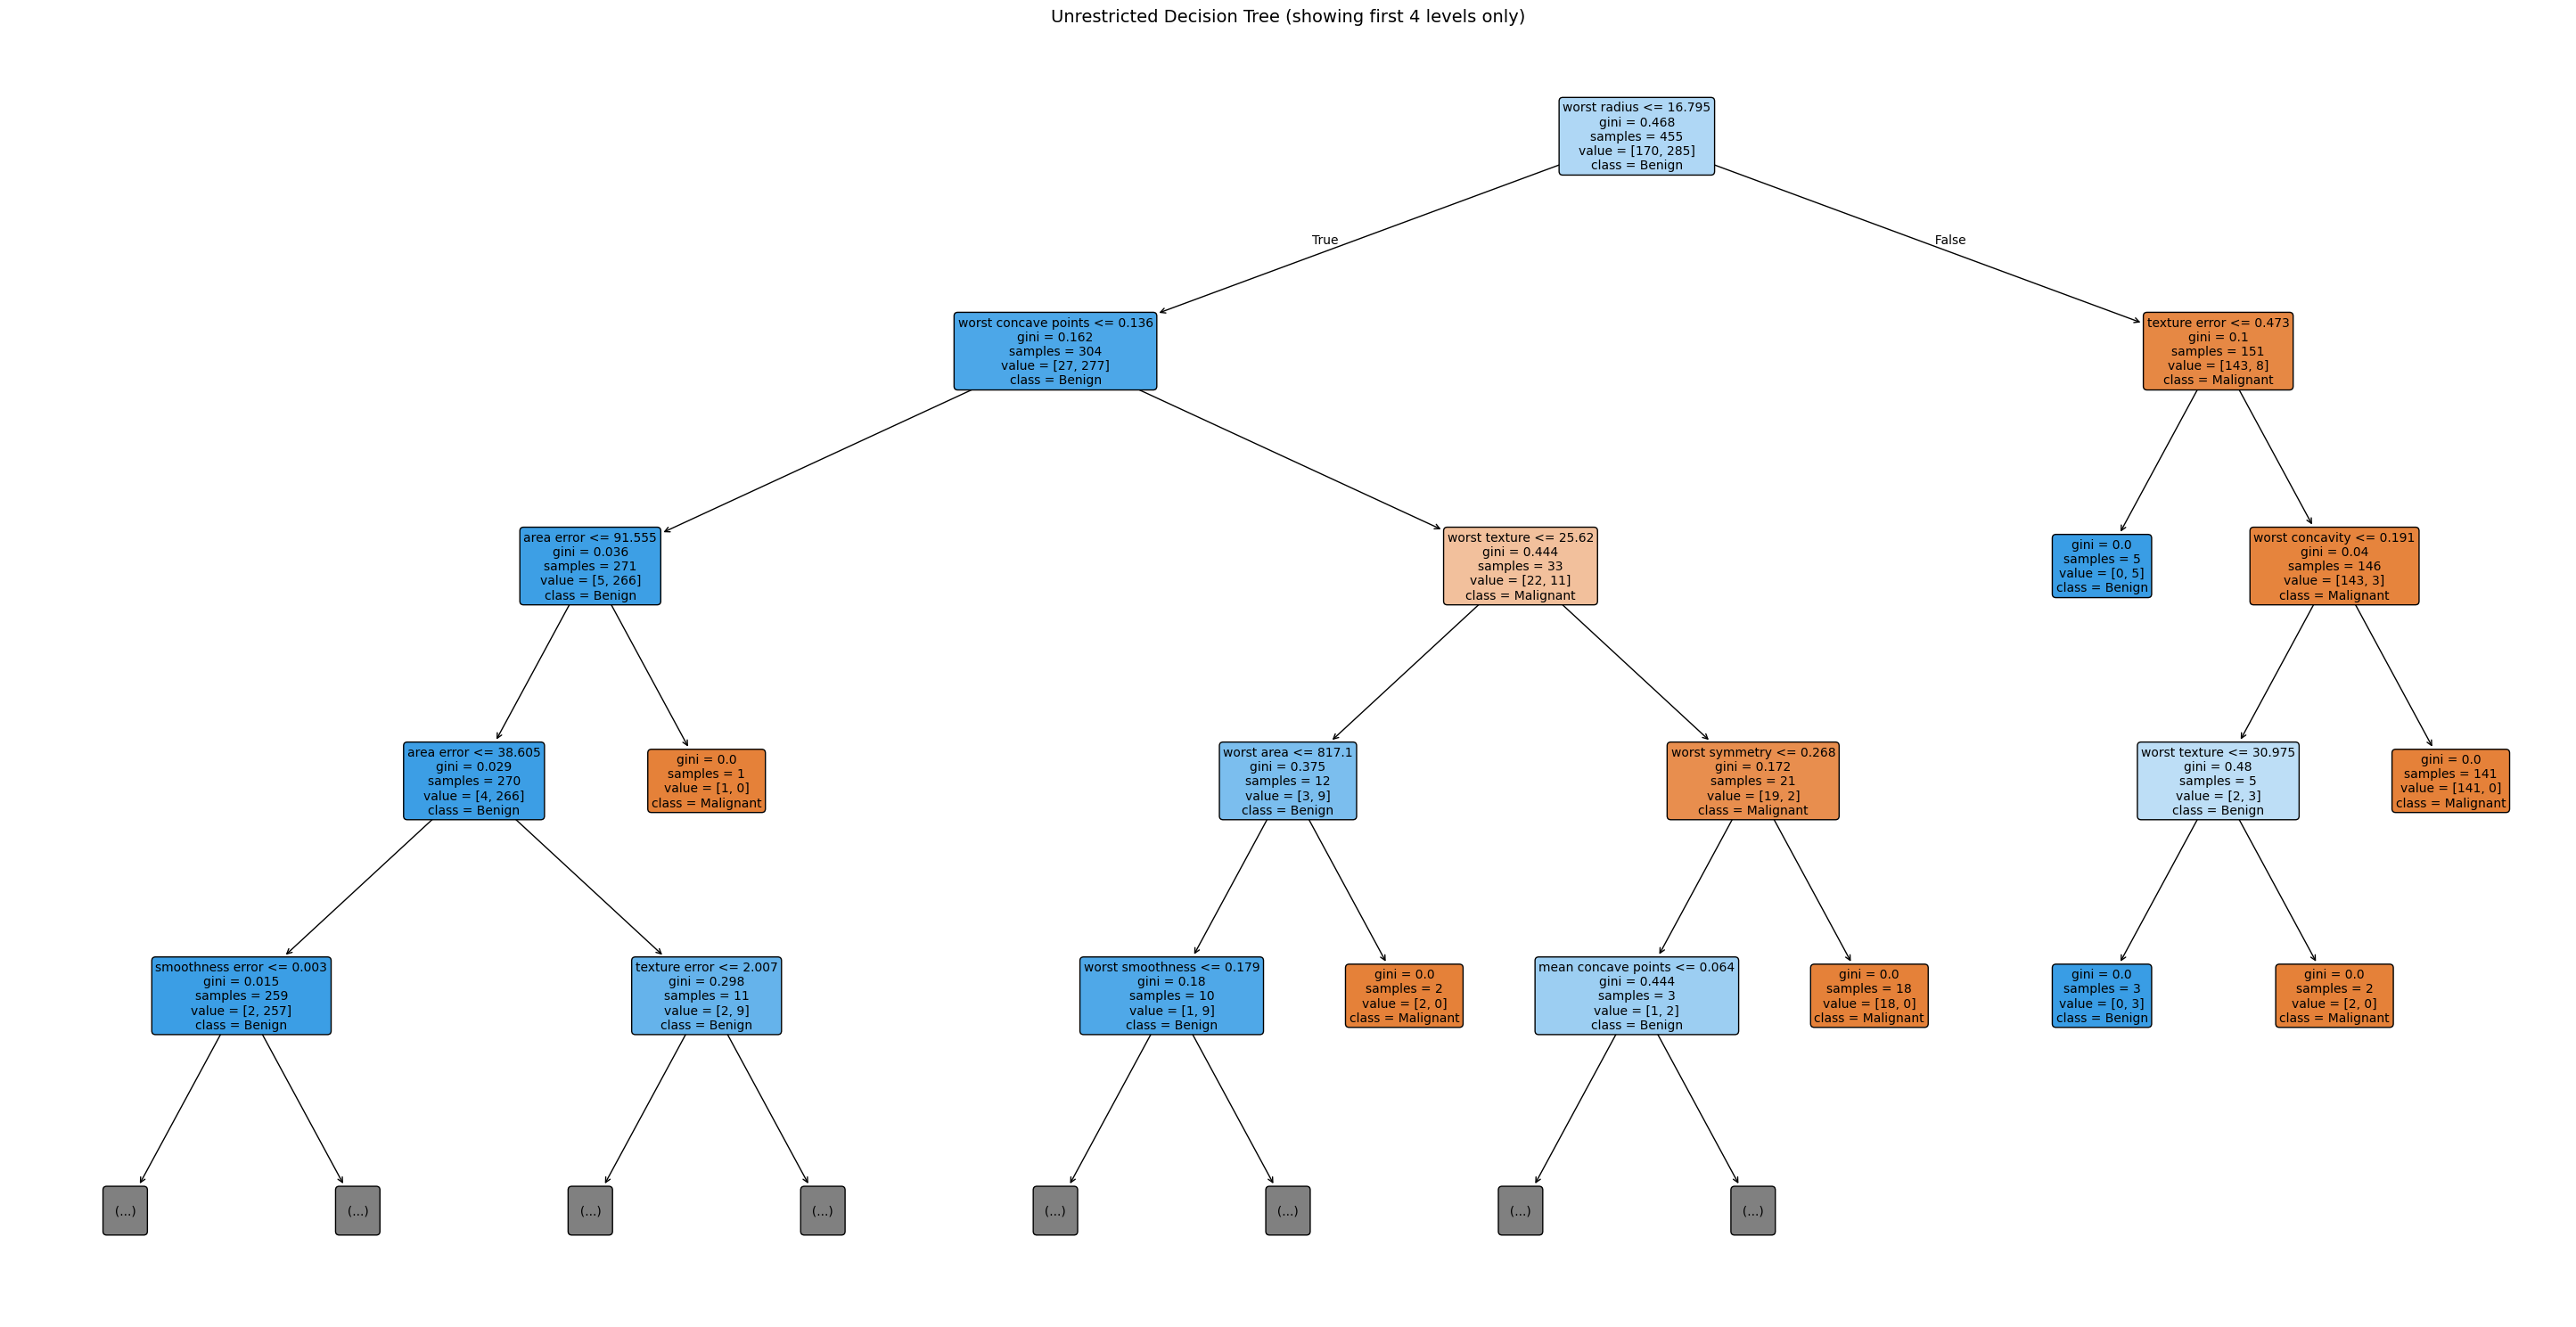

Note: Full tree has 7 levels — only showing 4 here.


In [8]:
# Create a large figure: figsize=(25, 12)

# Use plot_tree() to visualize the tree
# Set filled=True for colored nodes
# Set feature_names=X.columns
# Set class_names=['Malignant', 'Benign']
# Set fontsize=7 (small font to fit the large tree)
# Set max_depth=4 to only show the first 4 levels (otherwise unreadable)

# Add title: 'Unrestricted Decision Tree (showing first 4 levels)'
# Show the plot


plt.figure(figsize=(29,15 ))
plot_tree(dt_unrestricted, filled=True, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], fontsize=10,
          max_depth=4, rounded=True)
plt.title('Unrestricted Decision Tree (showing first 4 levels only)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Note: Full tree has {dt_unrestricted.get_depth()} levels — only showing 4 here.")


**What to observe:** Even showing only the first 4 levels, the tree is already complex. Each node shows: the feature and threshold used for the split, the Gini impurity, the number of samples, the class distribution, and the predicted class (determined by the majority). The color intensity indicates purity — darker colors mean more pure nodes.

---

## 9. Building a Pruned Decision Tree

Now let us build a properly constrained (pruned) tree. We set `max_depth=5` to limit how deep the tree can grow. This forces the tree to capture only the most important patterns and ignore noise.

**Task:** Train a Decision Tree with max_depth=5.

In [15]:
# Create DecisionTreeClassifier(max_depth=5, random_state=42)

# Fit on training data

# Compute and print training accuracy, test accuracy, and gap

# Print depth and number of leaves

# Compare with the unrestricted tree: is the gap smaller?

dt_pruned = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_pruned.fit(X_train, y_train)

train_acc_pr = accuracy_score(y_train, dt_pruned.predict(X_train))
test_acc_pr = accuracy_score(y_test, dt_pruned.predict(X_test))

gap_pr = train_acc_pr - test_acc_pr



print("=" * 55)
print("  PRUNED DECISION TREE (max_depth=5)")
print("=" * 55)
print(f"  Training Accuracy:  {train_acc_pr:.4f} ({train_acc_pr:.1%})")
print(f"  Test Accuracy:      {test_acc_pr:.4f} ({test_acc_pr:.1%})")
print(f"  Gap:                {gap_pr:.4f}")
print(f"  Tree Depth:         {dt_pruned.get_depth()}")
print(f"  Number of Leaves:   {dt_pruned.get_n_leaves()}")
print("=" * 55)

print(f"\n  Comparison with Unrestricted Tree:")
print(f"  {'Metric':<20} {'Unrestricted':>14} {'Pruned (d=5)':>14}")
print(f"  {'-'*20} {'-'*14} {'-'*14}")
print(f"  {'Train Accuracy':<20} {train_acc_ur:>14.4f} {train_acc_pr:>14.4f}")
print(f"  {'Test Accuracy':<20} {test_acc_ur:>14.4f} {test_acc_pr:>14.4f}")
print(f"  {'Gap':<20} {gap_ur:>14.4f} {gap_pr:>14.4f}")
print(f"  {'Depth':<20} {dt_unrestricted.get_depth():>14} {dt_pruned.get_depth():>14}")
print(f"  {'Leaves':<20} {dt_unrestricted.get_n_leaves():>14} {dt_pruned.get_n_leaves():>14}")


  PRUNED DECISION TREE (max_depth=5)
  Training Accuracy:  0.9934 (99.3%)
  Test Accuracy:      0.9211 (92.1%)
  Gap:                0.0724
  Tree Depth:         5
  Number of Leaves:   15

  Comparison with Unrestricted Tree:
  Metric                 Unrestricted   Pruned (d=5)
  -------------------- -------------- --------------
  Train Accuracy               1.0000         0.9934
  Test Accuracy                0.9123         0.9211
  Gap                          0.0877         0.0724
  Depth                             7              5
  Leaves                           19             15


**What to observe:** The training accuracy will be lower than 100% (the tree cannot memorize everything with limited depth), but the test accuracy should be **better** than the unrestricted tree. The train-test gap should be smaller — this is the hallmark of a well-regularized model. The tree is also much smaller and more interpretable.

### 9.1 Visualizing the Pruned Tree

With a maximum depth of 5, we can actually **read** the tree and understand every decision it makes. This is the interpretability advantage of Decision Trees.

**Task:** Visualize the pruned tree.

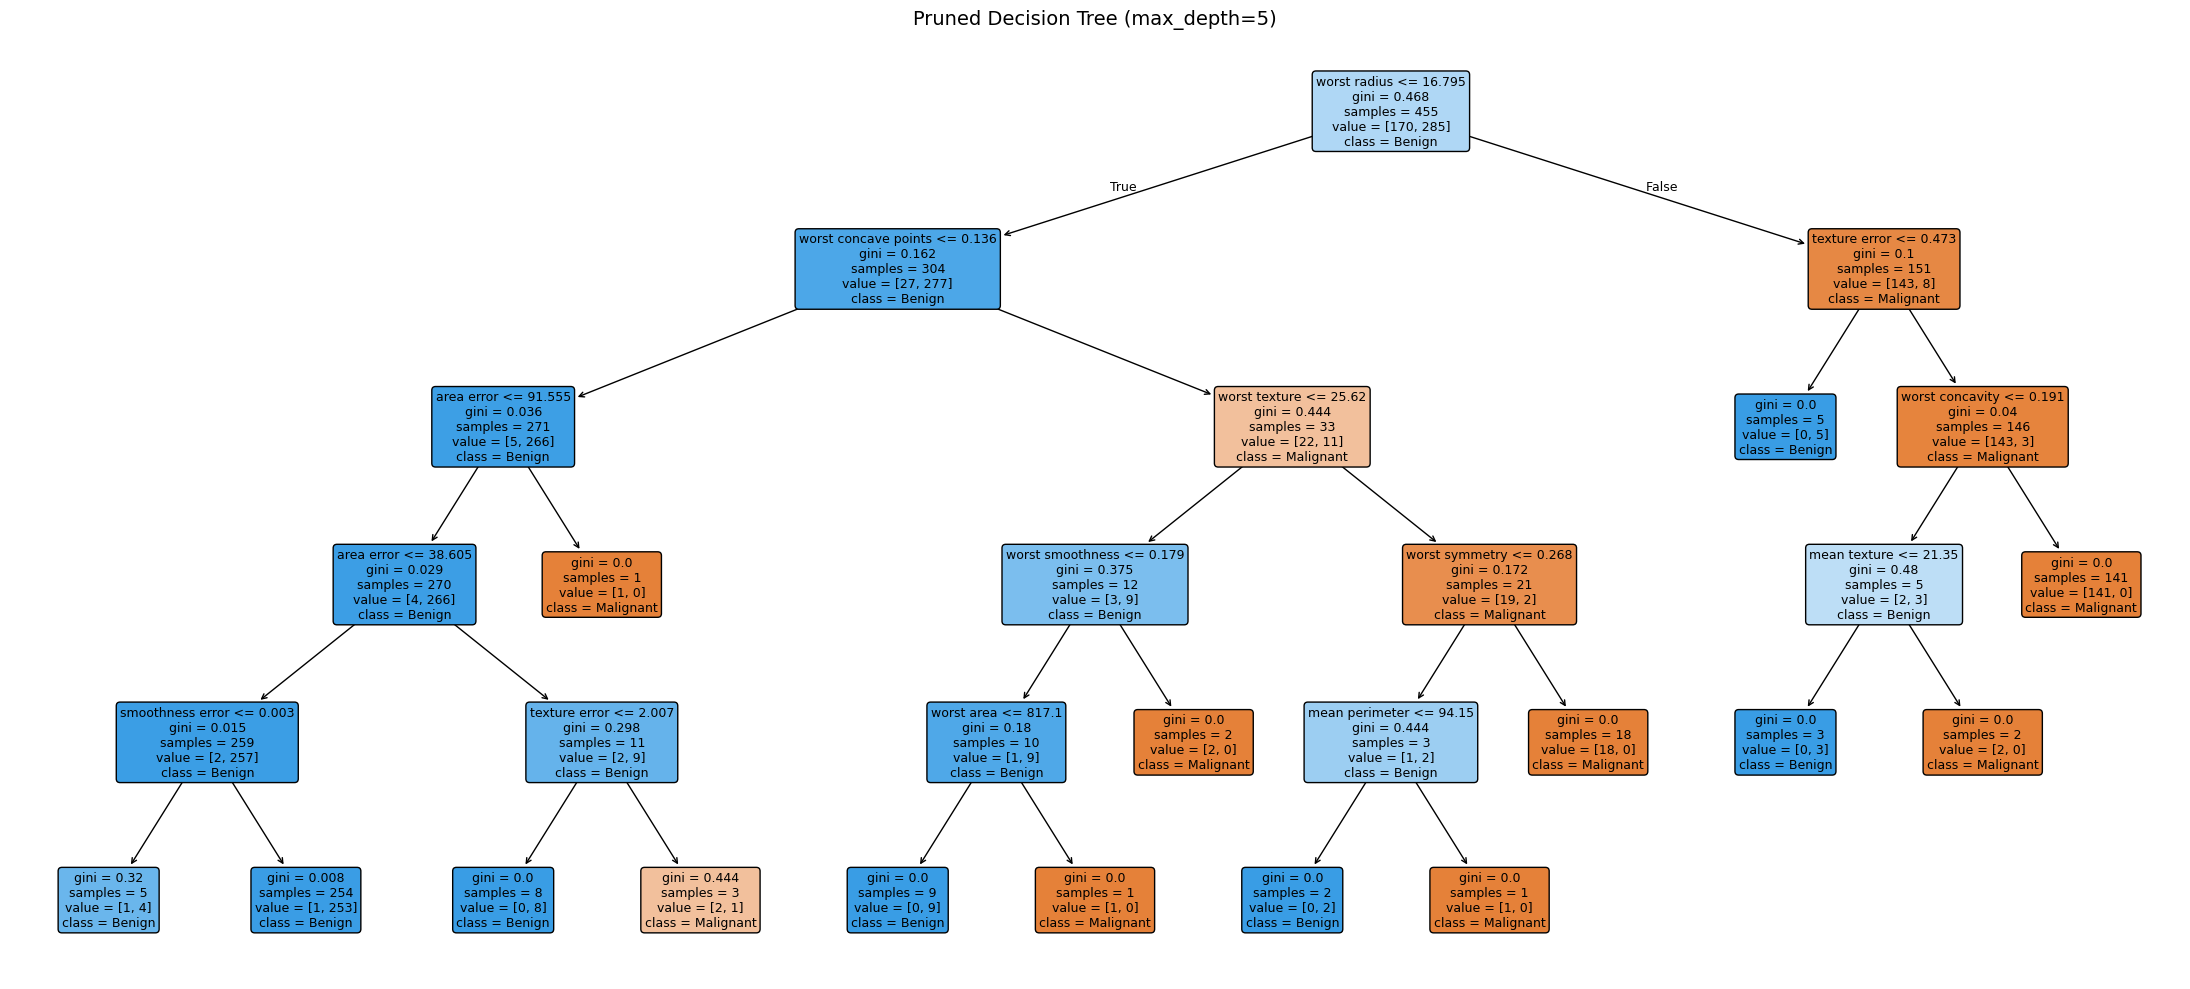

In [16]:
# Create a figure with figsize=(22, 10)

# Use plot_tree() with filled=True, feature_names, class_names
# Set fontsize=9 (readable now since tree is smaller)
# Set rounded=True for rounded boxes

# Add title: 'Pruned Decision Tree (max_depth=5)'
# Show the plot



plt.figure(figsize=(22, 10))
plot_tree(dt_pruned, filled=True, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], fontsize=9, rounded=True)
plt.title('Pruned Decision Tree (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()


### 9.2 Text Representation of the Tree

Sometimes a text representation is more useful than a visual one, especially for documentation or when the tree is too large to display cleanly.

**Task:** Print the tree rules as text.

In [17]:
# Use export_text() to print the tree as text rules
# Set feature_names=list(X.columns)

tree_rules = export_text(dt_pruned, feature_names=list(X.columns))
print(tree_rules)

# Print the output


|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- area error <= 38.60
|   |   |   |   |--- smoothness error <= 0.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- smoothness error >  0.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- area error >  38.60
|   |   |   |   |--- texture error <= 2.01
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- texture error >  2.01
|   |   |   |   |   |--- class: 0
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- worst smoothness <= 0.18
|   |   |   |   |--- worst area <= 817.10
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- worst area >  817.10
|   |   |   |   |   |--- class: 0
|   |   |   |--- worst smoothness >  0.18
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- worst symmetry <= 0.27
|   |   |   |   |--- mean perimeter <= 

**What to observe:** Read through the rules. Each line is an if-then condition. You can follow any path from top to bottom to understand exactly how the model classifies a particular sample. This level of transparency is unique to tree-based models.

---

## 10. Feature Importance

One of the great benefits of Decision Trees is that they naturally compute **feature importance**. Each feature's importance is calculated based on how much it contributed to reducing impurity across all splits where it was used.

Features that appear in higher (earlier) splits and produce larger impurity reductions are more important. Features that are never used in any split have zero importance.

**Task:** Extract and visualize feature importances.

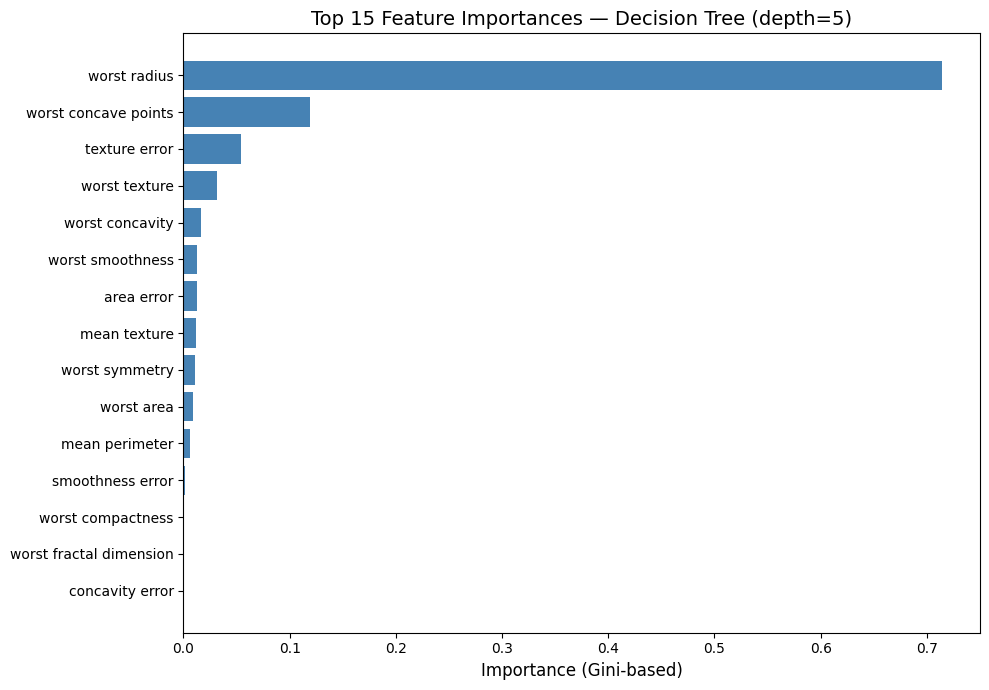


Top 5 most important features:
  worst radius                  : 0.7143
  worst concave points          : 0.1188
  texture error                 : 0.0539
  worst texture                 : 0.0315
  worst concavity               : 0.0167

Features with zero importance: 18 / 30


In [19]:
# Access model.feature_importances_

# Create a DataFrame with columns: 'Feature' and 'Importance'

# Sort by importance in descending order

# Select the top 15 features

# Create a horizontal bar chart with figsize=(10, 7)

# Add title: 'Top 15 Feature Importances — Decision Tree'
# Add x-label: 'Importance'
# Show the plot

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_pruned.feature_importances_
}).sort_values("Importance", ascending=True).tail(15)



plt.figure(figsize=(10, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Top 15 Feature Importances — Decision Tree (depth=5)', fontsize=14)
plt.xlabel('Importance (Gini-based)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
top5 = importance_df.tail(5).iloc[::-1]
for _, row in top5.iterrows():
    print(f"  {row['Feature']:30s}: {row['Importance']:.4f}")

n_zero = (dt_pruned.feature_importances_ == 0).sum()
print(f"\nFeatures with zero importance: {n_zero} / {len(X.columns)}")

**What to observe:** A few features will dominate the importance chart — these are the features the tree relies on most for its decisions. Many features will have zero or near-zero importance, meaning the tree found them unnecessary. Compare the top features here with the top coefficients from Logistic Regression (Day 48) and see if they agree.

---

## 11. Model Evaluation

### 11.1 Confusion Matrix

**Task:** Compute and visualize the confusion matrix for the pruned tree.

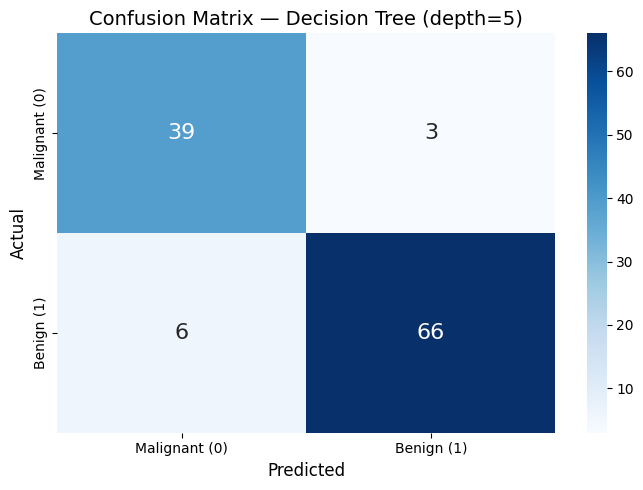

True Negatives  (TN): 39  — Correctly identified Malignant
False Positives (FP): 3  — Predicted Benign, was Malignant
False Negatives (FN): 6  — Predicted Malignant, was Benign
True Positives  (TP): 66  — Correctly identified Benign


In [21]:
# Predict on test set using the pruned model

# Compute confusion matrix

# Visualize with sns.heatmap, figsize=(7, 5)
# Use annot=True, fmt='d', cmap='Blues'
# Labels: ['Malignant (0)', 'Benign (1)']
# Add title: 'Confusion Matrix — Decision Tree (depth=5)'
# Show the plot

y_pred = dt_pruned.predict(X_test)
cm = confusion_matrix(y_test, y_pred)




plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix — Decision Tree (depth=5)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly identified Malignant")
print(f"False Positives (FP): {fp}  — Predicted Benign, was Malignant")
print(f"False Negatives (FN): {fn}  — Predicted Malignant, was Benign")
print(f"True Positives  (TP): {tp}  — Correctly identified Benign")

### 11.2 Classification Report

**Task:** Print the full classification report.

In [22]:
# Print classification_report with target_names
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))

               precision    recall  f1-score   support

Malignant (0)       0.87      0.93      0.90        42
   Benign (1)       0.96      0.92      0.94        72

     accuracy                           0.92       114
    macro avg       0.91      0.92      0.92       114
 weighted avg       0.92      0.92      0.92       114



### 11.3 ROC Curve and AUC

Decision Trees can output probability estimates using `predict_proba()`. These probabilities come from the class proportions in the leaf node where a sample lands.

**Task:** Plot the ROC curve and compute AUC.

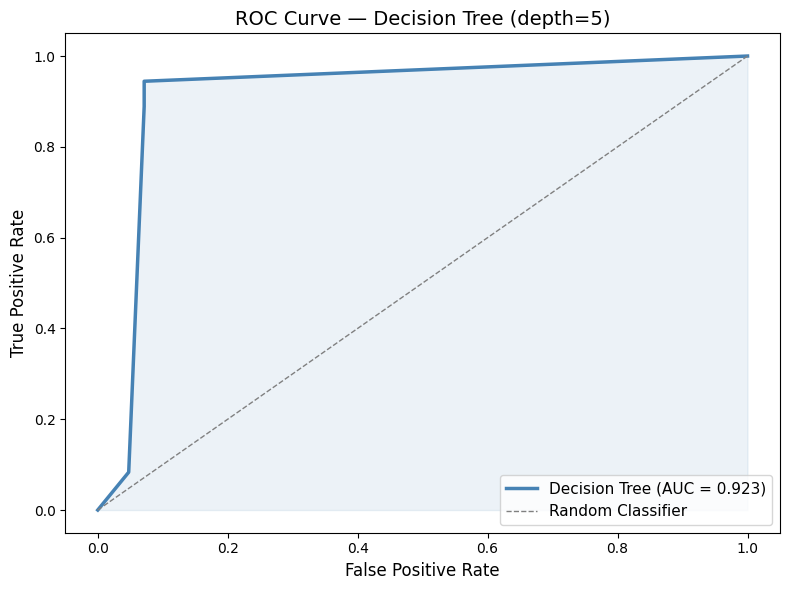

AUC Score: 0.9226


In [24]:
# Get predicted probabilities for class 1

# Compute ROC curve and AUC

# Plot with figsize=(8, 6)
# Include AUC in the label
# Plot diagonal baseline
# Add title, labels, legend
# Show the plot
y_prob = dt_pruned.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_pred)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Decision Tree (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1,
         label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

plt.title('ROC Curve — Decision Tree (depth=5)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

## 12. Finding the Best max_depth

We chose max_depth=5 somewhat arbitrarily. Let us systematically find the best depth by trying multiple values and plotting the training vs test accuracy at each depth. This is a simple but effective way to find the right amount of complexity.

**Task:** Sweep through max_depth values from 1 to 20 and plot the accuracy curves.

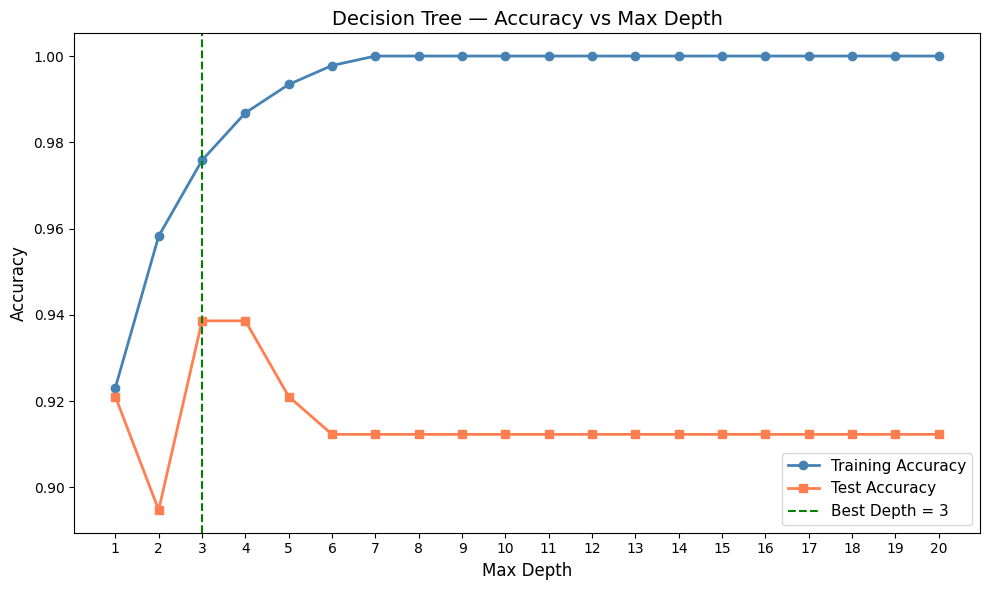

Best max_depth: 3
Best test accuracy: 0.9386
Train accuracy at best depth: 0.9758
Gap at best depth: 0.0372


In [25]:
# Create lists to store: depths, train_accuracies, test_accuracies

# For depth in range(1, 21):
#   Fit DecisionTreeClassifier(max_depth=depth, random_state=42)
#   Compute train and test accuracy
#   Append to lists

# Create a figure with figsize=(10, 6)
# Plot depth vs train accuracy (one line)
# Plot depth vs test accuracy (another line)
# Add a vertical line at the depth with the best test accuracy
# Add title: 'Decision Tree — Accuracy vs Max Depth'
# Add x-label: 'Max Depth'
# Add y-label: 'Accuracy'
# Add legend
# Show the plot

# Print the best depth and its test accuracy




depths = range(1, 21)
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))

best_depth = depths[np.argmax(test_accs)]
best_test_acc = max(test_accs)

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, 'o-', color='steelblue', linewidth=2, label='Training Accuracy')
plt.plot(depths, test_accs, 's-', color='coral', linewidth=2, label='Test Accuracy')
plt.axvline(x=best_depth, color='green', linestyle='--', linewidth=1.5,
            label=f'Best Depth = {best_depth}')

plt.title('Decision Tree — Accuracy vs Max Depth', fontsize=14)
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(depths)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Best max_depth: {best_depth}")
print(f"Best test accuracy: {best_test_acc:.4f}")
print(f"Train accuracy at best depth: {train_accs[best_depth - 1]:.4f}")
print(f"Gap at best depth: {train_accs[best_depth - 1] - best_test_acc:.4f}")


**What to observe:** This is the **bias-variance trade-off** visualized directly:

- At depth=1 (a stump), both train and test accuracy are relatively low — the model is **underfitting**.
- As depth increases, both curves improve. The test accuracy typically peaks somewhere around depth 3-7.
- Beyond the peak, training accuracy keeps climbing toward 100%, but test accuracy **plateaus or drops** — the model is starting to **overfit**.
- The widening gap between the two curves is the overfitting signal.

The optimal depth is where test accuracy is highest — this is the sweet spot.


## 13. Comparing All Models — Decision Tree vs Logistic Regression vs SVM

Let us bring together all the models we have learned so far and compare them on the same dataset.

**Task:** Train all three models and create a comparison table.

In [26]:
# Import LogisticRegression and SVC
# Import StandardScaler

# Scale features for LR and SVM (Decision Tree does not need scaling)

# Train:
#   LogisticRegression(random_state=42, max_iter=5000) on scaled data
#   SVC(kernel='rbf', probability=True, random_state=42) on scaled data
#   DecisionTreeClassifier(max_depth=best_depth, random_state=42) on unscaled data

# For each model: compute test accuracy and AUC

# Display comparison table


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale for LR and SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Train all models
models = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=5000), X_train_sc, X_test_sc),
    'SVM (RBF)': (SVC(kernel='rbf', probability=True, random_state=42), X_train_sc, X_test_sc),
    f'Decision Tree (d={best_depth})': (DecisionTreeClassifier(max_depth=best_depth, random_state=42), X_train, X_test)
}

comparison_results = []

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_p = model.predict(X_te)
    y_pr = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_test, y_p)
    auc_s = roc_auc_score(y_test, y_pr)

    comparison_results.append({
        'Model': name,
        'Test Accuracy': round(acc, 4),
        'AUC Score': round(auc_s, 4)
    })

comp_df = pd.DataFrame(comparison_results)
print("=" * 58)
print("  HEAD-TO-HEAD COMPARISON — Breast Cancer Dataset")
print("=" * 58)
print(comp_df.to_string(index=False))
print("=" * 58)
print("\nNote: Decision Tree does NOT require feature scaling.")
# 

  HEAD-TO-HEAD COMPARISON — Breast Cancer Dataset
              Model  Test Accuracy  AUC Score
Logistic Regression         0.9825     0.9954
          SVM (RBF)         0.9825     0.9950
Decision Tree (d=3)         0.9386     0.9446

Note: Decision Tree does NOT require feature scaling.


**What to observe:** Decision Trees often have slightly lower accuracy and AUC compared to Logistic Regression and SVM on this particular dataset. However, the Decision Tree is the most interpretable — you can read its rules and explain every prediction. In many real-world applications, this interpretability is worth a small trade-off in accuracy.


## 15. Summary and Key Takeaways

**Core Concept:**
- Decision Trees learn a series of if-then-else rules by recursively splitting the data
- At each node, the tree picks the feature and threshold that maximizes information gain (reduces impurity the most)
- Splits continue until the tree is pure or a stopping criterion is met

**Splitting Criteria:**

| Criterion | Formula | Range | Used For |
|-----------|---------|-------|----------|
| Gini Impurity | $1 - \sum p_i^2$ | 0 (pure) to 0.5 (mixed) | Classification (default) |
| Entropy | $-\sum p_i \log_2 p_i$ | 0 (pure) to 1 (mixed) | Classification (alternative) |
| MSE | Mean Squared Error | — | Regression |

**Overfitting and Pruning:**
- Unrestricted trees memorize training data → 100% training accuracy but poor generalization
- Control with: max_depth, min_samples_split, min_samples_leaf, max_leaf_nodes
- Find optimal depth by plotting train vs test accuracy

**Strengths:**
- Highly interpretable (you can read the rules)
- No feature scaling needed
- Handles non-linear relationships
- Built-in feature importance

**Weaknesses:**
- Very prone to overfitting without pruning
- Unstable — small changes in data can produce very different trees
- Greedy algorithm — does not guarantee globally optimal tree
